
## Sci-kit Metrics

We often want to test many models against each other in choosing the best one to use for a problem. The way we benchmark to choose the best one is through metrics.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

df  = pd.read_csv("creditcard.csv")[:80_000]
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [3]:
X = df.drop(columns=['Time', 'Amount', 'Class']).values
y = df['Class'].values
f"Shapes of X={X.shape} y={y.shape}, #Fraud Cases={y.sum()}"

'Shapes of X=(80000, 28) y=(80000,), #Fraud Cases=196'

In [4]:
from sklearn.linear_model import LogisticRegression

mod = LogisticRegression(class_weight={0: 1, 1: 2}, max_iter=1000)
mod.fit(X, y).predict(X).sum()

np.int64(172)

In [5]:
lr = LogisticRegression()

In [7]:
from sklearn.ensemble import IsolationForest
mod = IsolationForest().fit(X)
np.where(mod.predict(X) == -1, 1, 0)

array([0, 0, 0, ..., 0, 0, 0], shape=(80000,))

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score , recall_score, make_scorer

def min_recall_precision(est, X, y_true, sample_weight=None):
    y_pred = est.predict(X)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    return min(recall, precision)

grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid={'class_weight': [{0: 1, 1: v} for v in np.linspace(1, 20, 30)]},
    scoring={'precision': make_scorer(precision_score), 
             'recall': make_scorer(recall_score), 
             'min_both': min_recall_precision},
    refit='min_both',
    return_train_score=True,
    cv=10,
    n_jobs=-1
)

grid.fit(X, y)
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,...,split2_train_min_both,split3_train_min_both,split4_train_min_both,split5_train_min_both,split6_train_min_both,split7_train_min_both,split8_train_min_both,split9_train_min_both,mean_train_min_both,std_train_min_both
0,1.194782,0.670336,0.208189,0.277528,"{0: 1, 1: 1.0}","{'class_weight': {0: 1, 1: 1.0}}",1.000000,0.463415,0.583333,1.000000,...,0.632768,0.559322,0.573864,0.573864,0.562500,0.619318,0.625000,0.602273,0.611049,0.051750
1,0.957097,0.250602,0.061522,0.022016,"{0: 1, 1: 1.6551724137931034}","{'class_weight': {0: 1, 1: 1.6551724137931034}}",1.000000,0.441860,0.583333,1.000000,...,0.689266,0.627119,0.670455,0.647727,0.630682,0.681818,0.698864,0.687500,0.681366,0.053324
2,0.613323,0.076123,0.042965,0.005304,"{0: 1, 1: 2.310344827586207}","{'class_weight': {0: 1, 1: 2.310344827586207}}",1.000000,0.431818,0.583333,1.000000,...,0.734463,0.683616,0.715909,0.693182,0.681818,0.721591,0.744318,0.727273,0.723889,0.044372
3,0.551223,0.059188,0.054313,0.020184,"{0: 1, 1: 2.9655172413793105}","{'class_weight': {0: 1, 1: 2.9655172413793105}}",1.000000,0.431818,0.583333,1.000000,...,0.779661,0.706215,0.744318,0.732955,0.715909,0.755682,0.772727,0.738636,0.749413,0.039118
4,0.578374,0.085069,0.035436,0.002997,"{0: 1, 1: 3.6206896551724137}","{'class_weight': {0: 1, 1: 3.6206896551724137}}",1.000000,0.431818,0.583333,1.000000,...,0.819209,0.734463,0.761364,0.744318,0.732955,0.778409,0.784091,0.761364,0.770939,0.035655
5,0.594366,0.113733,0.043637,0.016159,"{0: 1, 1: 4.275862068965517}","{'class_weight': {0: 1, 1: 4.275862068965517}}",1.000000,0.431818,0.583333,1.000000,...,0.841808,0.774011,0.778409,0.789773,0.784091,0.789773,0.801136,0.772727,0.794190,0.029023
6,0.674964,0.102416,0.047358,0.017605,"{0: 1, 1: 4.931034482758621}","{'class_weight': {0: 1, 1: 4.931034482758621}}",1.000000,0.431818,0.583333,1.000000,...,0.847458,0.790960,0.795455,0.808989,0.795455,0.801136,0.805556,0.795455,0.810148,0.022218
7,0.590129,0.062149,0.035973,0.005426,"{0: 1, 1: 5.586206896551724}","{'class_weight': {0: 1, 1: 5.586206896551724}}",1.000000,0.431818,0.583333,1.000000,...,0.842697,0.805556,0.802198,0.806630,0.798883,0.812500,0.806630,0.804469,0.814279,0.018862
8,0.659203,0.075891,0.036745,0.005254,"{0: 1, 1: 6.241379310344827}","{'class_weight': {0: 1, 1: 6.241379310344827}}",1.000000,0.422222,0.583333,0.947368,...,0.842697,0.807692,0.805405,0.812155,0.800000,0.806630,0.807487,0.807692,0.816528,0.019387
9,0.571499,0.052010,0.041501,0.010817,"{0: 1, 1: 6.896551724137931}","{'class_weight': {0: 1, 1: 6.896551724137931}}",0.944444,0.422222,0.583333,0.947368,...,0.837989,0.808743,0.805405,0.813187,0.802198,0.812155,0.808511,0.809783,0.817216,0.018230



By default, Logistic Regression simply uses accuracy as the metric for success. However, you can also import other metrics to judge a model off of. Two other metrics are:

* **Precision:** Given that I predict fraud, how accurate am I.
* **Recall:** Did I get all the fraud cases.

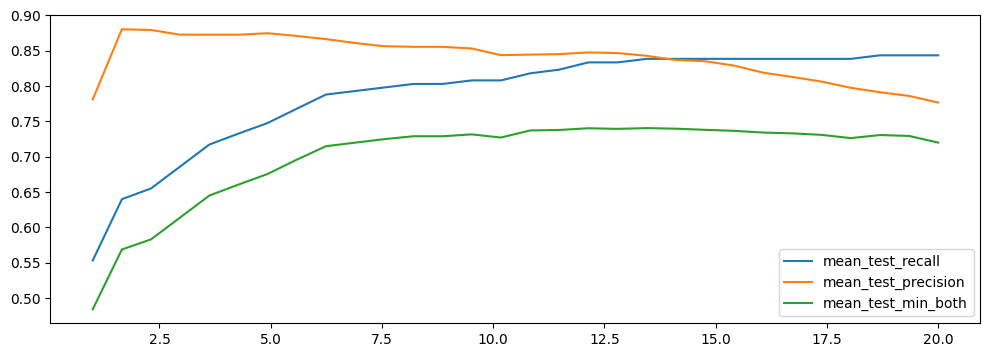

In [11]:
plt.figure(figsize=(12, 4))
df_results = pd.DataFrame(grid.cv_results_)
for score in ['mean_test_recall', 'mean_test_precision', 'mean_test_min_both']:
    plt.plot([_[1] for _ in df_results['param_class_weight']], 
             df_results[score], 
             label=score)
plt.legend();

In [12]:
def outlier_precision(y_true, y_pred):
    return precision_score(y_true, np.where(y_pred == -1, 1, 0))